# Problem Title - Scratch Mode
Issue: #2

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [3]:
url = "https://raw.githubusercontent.com/PriyaVerma06/Logistic-Regression/main/dataset.csv"
df = pd.read_csv(url)

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())

df.head()

Shape: (768, 9)

Columns:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [4]:
# Features and target
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values.reshape(-1, 1)

# Normalize features (important for gradient descent)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    epsilon = 1e-8
    return -np.mean(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))

def compute_accuracy(y, y_pred):
    preds = (y_pred >= 0.5).astype(int)
    return np.mean(preds == y)

# Full Batch Gradient Descent
def train_full_batch(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    weights = np.zeros((n, 1))
    losses = []

    for epoch in range(epochs):
        z = np.dot(X, weights)
        y_pred = sigmoid(z)

        loss = compute_loss(y, y_pred)
        losses.append(loss)

        gradient = (1/m) * np.dot(X.T, (y_pred - y))
        weights -= lr * gradient

    return weights, losses

# Mini-batch + Learning Rate Decay
def train_mini_batch(X, y, lr=0.01, epochs=200, batch_size=32, decay=0.01):
    m, n = X.shape
    weights = np.zeros((n, 1))
    losses = []

    for epoch in range(epochs):
        lr_t = lr / (1 + decay * epoch)

        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            z = np.dot(X_batch, weights)
            y_pred = sigmoid(z)

            gradient = (1/len(X_batch)) * np.dot(X_batch.T, (y_pred - y_batch))
            weights -= lr_t * gradient

        # track full loss
        y_pred_full = sigmoid(np.dot(X, weights))
        losses.append(compute_loss(y, y_pred_full))

    return weights, losses

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

In [6]:
# Train both models
w_full, loss_full = train_full_batch(X_train, y_train)
w_mini, loss_mini = train_mini_batch(X_train, y_train)

## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

Full Batch Accuracy: 0.7662337662337663
Mini-Batch + LR Decay Accuracy: 0.7662337662337663


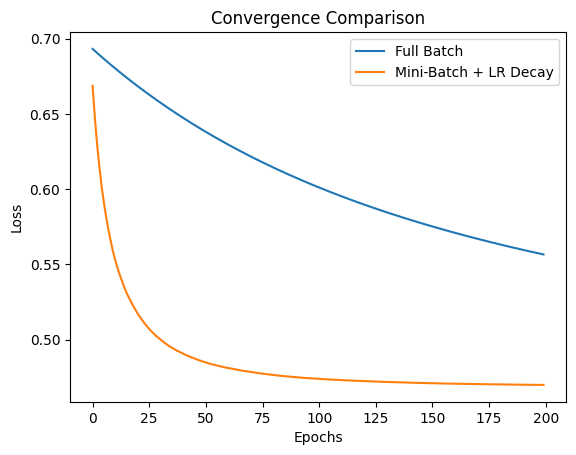

In [7]:
# Predictions
y_pred_full = sigmoid(np.dot(X_test, w_full))
y_pred_mini = sigmoid(np.dot(X_test, w_mini))

# Accuracy
acc_full = compute_accuracy(y_test, y_pred_full)
acc_mini = compute_accuracy(y_test, y_pred_mini)

print("Full Batch Accuracy:", acc_full)
print("Mini-Batch + LR Decay Accuracy:", acc_mini)

# Plot convergence
plt.plot(loss_full, label="Full Batch")
plt.plot(loss_mini, label="Mini-Batch + LR Decay")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.show()

## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

## Ans.1
-Implemented sigmoid activation function

-Binary cross-entropy loss

-Full-batch gradient descent

-Mini-batch gradient descent

-Learning rate decay strategy


## Ans.2
-Mini-batch converges faster initially due to frequent updates

-Learning rate decay stabilizes training in later epochs

-Full-batch shows smoother but slower convergence

-Mini-batch introduces slight noise but improves speed


##Ans.3
-Mini-batch balances speed and stability

-Learning rate scheduling is crucial for convergence

-Scratch implementation deepens understanding of optimization

-Proper preprocessing (normalization) is essential